In [ ]:
using Pkg
Pkg.add(["Images", "FileIO", "ImageIO", "PlotlyJS", "Printf"])

In [1]:
using Images, FileIO, Random, Statistics, Printf, PlotlyJS

IMG_SIZE = 150
OUTPUT_DIR = "lab19"
mkpath(OUTPUT_DIR)

function draw_line!(img::Matrix{Float64}, x1::Int, y1::Int, x2::Int, y2::Int; thick::Int=1)
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    sx = x1 < x2 ? 1 : -1
    sy = y1 < y2 ? 1 : -1
    err = dx - dy
    while true
        for δx in -thick:thick, δy in -thick:thick
            px, py = x1 + δx, y1 + δy
            if 1 <= px <= IMG_SIZE && 1 <= py <= IMG_SIZE
                img[py, px] = 0.0
            end
        end
        x1 == x2 && y1 == y2 && break
        e2 = 2 * err
        if e2 > -dy; err -= dy; x1 += sx; end
        if e2 < dx; err += dx; y1 += sy; end
    end
end

function mutate_gene(genes::Vector{Int}, ranges::Vector{Tuple{Int,Int}})::Vector{Int}
    g = copy(genes)
    i = rand(1:length(g))
    g[i] += rand([-1, 1])
    g[i] = clamp(g[i], ranges[i][1], ranges[i][2])
    return g
end


function distance_transform(mask::BitMatrix)::Matrix{Float64}
    h, w = size(mask)
    dist = fill(Inf, h, w)
    queue = Tuple{Int,Int}[]
    for y in 1:h, x in 1:w
        if mask[y, x]
            dist[y, x] = 0.0
            push!(queue, (y, x))
        end
    end
    head = 1
    while head <= length(queue)
        cy, cx = queue[head]
        head += 1
        for dy in -1:1, dx in -1:1
            (dy == 0 && dx == 0) && continue
            ny, nx = cy + dy, cx + dx
            (1 <= ny <= h && 1 <= nx <= w) || continue
            nd = dist[cy, cx] + sqrt(Float64(dy^2 + dx^2))
            if nd < dist[ny, nx]
                dist[ny, nx] = nd
                push!(queue, (ny, nx))
            end
        end
    end
    return dist
end

function combined_distance(a::Matrix{Float64}, b::Matrix{Float64}; alpha::Float64=0.65)::Float64
    a_black = a .< 0.5
    b_black = b .< 0.5
    na, nb = sum(a_black), sum(b_black)
    manhattan = sum(abs.(a .- b)) / length(a)
    if na == 0 || nb == 0
        return manhattan * 100.0
    end
    dt_a = distance_transform(a_black)
    dt_b = distance_transform(b_black)
    chamfer = (mean(dt_a[b_black]) + mean(dt_b[a_black])) / 2.0
    return alpha * chamfer + (1.0 - alpha) * manhattan * 100.0
end


TARGET_PATH = "target_edges.png"
target_raw = load(TARGET_PATH)
target = Float64.(Gray.(imresize(target_raw, (IMG_SIZE, IMG_SIZE))))
save(joinpath(OUTPUT_DIR, "target.png"), Gray.(target))
println("Цель: $(size(target)), чёрных пикселей: $(@sprintf("%.1f", 100*(1-mean(target))))%")


function make_stems(g::AbstractVector{Int})
    return [
        (0, g[1]), (g[2], g[3]), (g[4], 0), (g[5], -g[6]),
        (0, -g[7]), (-g[5], -g[6]), (-g[4], 0), (-g[2], g[3])
    ]
end

function tree_render(stems, len::Int, dir::Int, pos::Tuple{Float64,Float64})
    segs = Tuple{Tuple{Float64,Float64}, Tuple{Float64,Float64}}[]
    nd = mod(dir, 8) + 1
    dx, dy = stems[nd]
    np_ = (pos[1] + len * dx, pos[2] + len * dy)
    push!(segs, (pos, np_))
    if len > 1
        append!(segs, tree_render(stems, len - 1, dir + 1, np_))
        append!(segs, tree_render(stems, len - 1, dir - 1, np_))
    end
    return segs
end

function segs_to_image(segs; cx_off::Int=0, cy_off::Int=0,
                       scale_mult::Float64=1.0, line_thick::Int=1)::Matrix{Float64}
    isempty(segs) && return ones(IMG_SIZE, IMG_SIZE)
    ax = Float64[]; ay = Float64[]
    for (s, f) in segs
        push!(ax, s[1], f[1]); push!(ay, s[2], f[2])
    end
    w = max(abs(minimum(ax)), maximum(ax)) * 2
    h = max(abs(minimum(ay)), maximum(ay)) * 2
    max(w, h) == 0 && return ones(IMG_SIZE, IMG_SIZE)
    factor = (IMG_SIZE - 10) / max(w, h) * scale_mult
    cx = IMG_SIZE ÷ 2 + cx_off
    cy = IMG_SIZE ÷ 2 + cy_off
    img = ones(IMG_SIZE, IMG_SIZE)
    for (s, f) in segs
        draw_line!(img,
            round(Int, s[1]*factor + cx), round(Int, -s[2]*factor + cy),
            round(Int, f[1]*factor + cx), round(Int, -f[2]*factor + cy); thick=line_thick)
    end
    return img
end


CLASSIC_RANGES = Tuple{Int,Int}[
    (-9,9), (-9,9), (-9,9), (-9,9), (-9,9), (-9,9), (-9,9), (-9,9), (2,7)
]

function classic_draw(genes::Vector{Int})::Matrix{Float64}
    stems = make_stems(genes[1:8])
    segs = try
        tree_render(stems, genes[9], 0, (0.0, 0.0))
    catch e
        e isa StackOverflowError ? Tuple{Tuple{Float64,Float64},Tuple{Float64,Float64}}[] : rethrow()
    end
    return segs_to_image(segs; line_thick=1)
end


N_TREES = 4

NEO_RANGES = Tuple{Int,Int}[
    (-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(2,6),
    (-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(2,6),
    (-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(2,6),
    (-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(2,6),
    (-9,9),(-9,9),(-9,9),(-9,9),
    (-9,9),(-9,9),(-9,9),(-9,9),
    (1,5),(1,5),(1,5),(1,5)
]

function neo_draw(genes::Vector{Int})::Matrix{Float64}
    img = ones(IMG_SIZE, IMG_SIZE)
    for t in 1:N_TREES
        base = (t - 1) * 9
        tg = genes[base+1:base+9]
        off_base = N_TREES * 9
        ox = genes[off_base + t]
        oy = genes[off_base + N_TREES + t]
        sc = genes[off_base + 2*N_TREES + t]
        stems = make_stems(tg[1:8])
        segs = try
            tree_render(stems, tg[9], 0, (0.0, 0.0))
        catch e
            e isa StackOverflowError ? Tuple{Tuple{Float64,Float64},Tuple{Float64,Float64}}[] : rethrow()
        end
        isempty(segs) && continue
        ax = [p[1] for s in segs for p in s]
        ay = [p[2] for s in segs for p in s]
        w = max(abs(minimum(ax)), maximum(ax)) * 2
        h = max(abs(minimum(ay)), maximum(ay)) * 2
        max(w, h) == 0 && continue
        factor = (IMG_SIZE - 10) / max(w, h) * (sc / 3.0)
        cx = IMG_SIZE ÷ 2 + ox * 5
        cy = IMG_SIZE ÷ 2 + oy * 5
        for (s, f) in segs
            draw_line!(img,
                round(Int, s[1]*factor + cx), round(Int, -s[2]*factor + cy),
                round(Int, f[1]*factor + cx), round(Int, -f[2]*factor + cy); thick=0)
        end
    end
    return img
end


function evolve(draw_fn::Function, ranges::Vector{Tuple{Int,Int}},
                target::Matrix{Float64};
                n_offspring::Int=80, stag_limit::Int=80,
                max_gen::Int=1500, seed::Int=42)
    Random.seed!(seed)
    parent = [rand(lo:hi) for (lo, hi) in ranges]
    parent_img = draw_fn(parent)
    best_dist = combined_distance(parent_img, target)
    history = Float64[best_dist]
    snapshots = Pair{Int, Matrix{Float64}}[0 => copy(parent_img)]
    gen = 0
    stag = 0
    while stag < stag_limit && gen < max_gen
        gen += 1
        improved = false
        for _ in 1:n_offspring
            child = mutate_gene(parent, ranges)
            child_img = draw_fn(child)
            dist = combined_distance(child_img, target)
            if dist < best_dist
                best_dist = dist
                parent = child
                parent_img = child_img
                improved = true
            end
        end
        improved ? (stag = 0) : (stag += 1)
        push!(history, best_dist)
        if gen <= 15 || gen % 25 == 0
            push!(snapshots, gen => copy(parent_img))
        end
        if gen % 100 == 0
            println("  Gen $gen | Dist: $(@sprintf("%.3f", best_dist)) | Stag: $stag")
        end
    end
    push!(snapshots, gen => copy(parent_img))
    return parent, parent_img, history, snapshots
end


function side_by_side(biomorph::Matrix{Float64}, tgt::Matrix{Float64})
    hcat(tgt, ones(IMG_SIZE, 5), biomorph)
end

function save_experiment(prefix::String, result, tgt::Matrix{Float64})
    genes, img, hist, snaps = result
    save(joinpath(OUTPUT_DIR, "$(prefix)_comparison.png"), Gray.(side_by_side(img, tgt)))

    n = min(16, length(snaps))
    idxs = round.(Int, range(1, length(snaps), length=n))
    grid = ones(4*(IMG_SIZE+5)-5, 4*(IMG_SIZE+5)-5)
    for (k, i) in enumerate(idxs)
        r, c = (k-1) ÷ 4, (k-1) % 4
        grid[r*(IMG_SIZE+5)+1 : r*(IMG_SIZE+5)+IMG_SIZE,
             c*(IMG_SIZE+5)+1 : c*(IMG_SIZE+5)+IMG_SIZE] .= snaps[i].second
    end
    save(joinpath(OUTPUT_DIR, "$(prefix)_grid.png"), Gray.(grid))

    gif_frames = [Gray.(side_by_side(s.second, tgt)) for s in snaps]
    save(joinpath(OUTPUT_DIR, "$(prefix)_evolution.gif"), cat(gif_frames...; dims=3); fps=5)

    println("Сохранено: $(prefix)_comparison/grid/evolution")
end


println("=" ^ 60)
println("ЭКСПЕРИМЕНТ 1: Классика (9 генов)")
println("=" ^ 60)

best_classic = nothing
for run in 0:2
    genes, img, hist, snaps = evolve(classic_draw, CLASSIC_RANGES, target;
                                      n_offspring=80, stag_limit=80, max_gen=1000, seed=run*111)
    println("Run $run: gen=$(length(hist)-1), dist=$(@sprintf("%.3f", hist[end])), genes=$genes")
    if best_classic === nothing || hist[end] < best_classic[3][end]
        best_classic = (genes, img, hist, snaps)
    end
end
println("Лучший: dist=$(@sprintf("%.3f", best_classic[3][end]))")
save_experiment("classic", best_classic, target)


println("\n" * "=" ^ 60)
println("ЭКСПЕРИМЕНТ 2: Неоклассика (48 генов, 4 дерева)")
println("=" ^ 60)

best_neo = nothing
for run in 0:2
    genes, img, hist, snaps = evolve(neo_draw, NEO_RANGES, target;
                                      n_offspring=100, stag_limit=80, max_gen=1000, seed=run*222+7)
    println("Run $run: gen=$(length(hist)-1), dist=$(@sprintf("%.3f", hist[end]))")
    if best_neo === nothing || hist[end] < best_neo[3][end]
        best_neo = (genes, img, hist, snaps)
    end
end
println("Лучший: dist=$(@sprintf("%.3f", best_neo[3][end]))")
save_experiment("neo", best_neo, target)


p = plot([
    scatter(x=0:length(best_classic[3])-1, y=best_classic[3],
            mode="lines", name="Классика (9 генов)",
            line=attr(color="royalblue", width=2)),
    scatter(x=0:length(best_neo[3])-1, y=best_neo[3],
            mode="lines", name="Неоклассика (48 генов)",
            line=attr(color="crimson", width=2))
], Layout(
    title="Сходимость эволюции биоморф",
    xaxis_title="Поколение",
    yaxis_title="Расстояние (Chamfer + Manhattan)",
    template="plotly_white",
    width=900, height=500,
    legend=attr(x=0.6, y=0.95)
))
savefig(p, joinpath(OUTPUT_DIR, "convergence.html"))
display(p)

println("\nРезультаты в: $OUTPUT_DIR/")

WebIO._IJuliaInit()

Цель: (150, 150), чёрных пикселей: 6.8%
ЭКСПЕРИМЕНТ 1: Классика (9 генов)
Run 0: gen=82, dist=7.694, genes=[-3, -2, 9, -8, 2, -6, -7, 4, 2]
Run 1: gen=81, dist=7.639, genes=[1, -1, -4, -6, -2, 1, -2, 7, 2]
Run 2: gen=82, dist=7.123, genes=[-2, 1, 4, -3, 6, 0, -5, -9, 4]
Лучший: dist=7.123
Сохранено: classic_comparison/grid/evolution

ЭКСПЕРИМЕНТ 2: Неоклассика (48 генов, 4 дерева)
Run 0: gen=86, dist=6.508
Run 1: gen=87, dist=5.366
Run 2: gen=89, dist=6.018
Лучший: dist=5.366
Сохранено: neo_comparison/grid/evolution


data: [
  "scatter with fields line, mode, name, type, x, and y",
  "scatter with fields line, mode, name, type, x, and y"
]

layout: "layout with fields height, legend, margin, template, title, width, xaxis, and yaxis"


Результаты в: lab19/


In [ ]:
using Images, FileIO, Random, Statistics, Printf, PlotlyJS

IMG_SIZE = 150
N_TREES = 1 #8
TREE_G = 14  # 8 форма + 1 глубина + 3 RGB + 1 толщина + 1 направление
OUTPUT_DIR = "lab19"
mkpath(OUTPUT_DIR)

#  Отрисовка RGB-линии
function draw_line_rgb!(img::Array{Float64,3}, x1::Int, y1::Int, x2::Int, y2::Int,
                        r::Float64, g::Float64, b::Float64; thick::Int=1)
    dx = abs(x2 - x1); dy = abs(y2 - y1)
    sx = x1 < x2 ? 1 : -1; sy = y1 < y2 ? 1 : -1
    err = dx - dy
    while true
        for δx in -thick:thick, δy in -thick:thick
            px, py = x1 + δx, y1 + δy
            if 1 <= px <= IMG_SIZE && 1 <= py <= IMG_SIZE
                img[py, px, 1] = r; img[py, px, 2] = g; img[py, px, 3] = b
            end
        end
        x1 == x2 && y1 == y2 && break
        e2 = 2 * err
        if e2 > -dy; err -= dy; x1 += sx; end
        if e2 < dx; err += dx; y1 += sy; end
    end
end

#  Быстрый DT (двухпроходный) 
function fast_dt!(dist::Matrix{Float64}, mask::BitMatrix)
    h, w = size(mask)
    big = Float64(h + w)
    @inbounds for y in 1:h, x in 1:w
        dist[y, x] = mask[y, x] ? 0.0 : big
    end
    @inbounds for y in 1:h, x in 1:w
        y > 1 && (dist[y, x] = min(dist[y, x], dist[y-1, x] + 1.0))
        x > 1 && (dist[y, x] = min(dist[y, x], dist[y, x-1] + 1.0))
    end
    @inbounds for y in h:-1:1, x in w:-1:1
        y < h && (dist[y, x] = min(dist[y, x], dist[y+1, x] + 1.0))
        x < w && (dist[y, x] = min(dist[y, x], dist[y, x+1] + 1.0))
    end
end

#  Диапазоны генов 
RANGES = Tuple{Int,Int}[]
for _ in 1:N_TREES
    append!(RANGES, [(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9)])
    push!(RANGES, (2, 10))
    append!(RANGES, [(0,255),(0,255),(0,255)])
    push!(RANGES, (1, 8))
    push!(RANGES, (0, 7))
end
append!(RANGES, [(0,255),(0,255),(0,255)])
append!(RANGES, [(-15,15) for _ in 1:N_TREES])
append!(RANGES, [(-15,15) for _ in 1:N_TREES])
append!(RANGES, [(1,8) for _ in 1:N_TREES])

#  Мутация 
function mutate_gene(genes::Vector{Int}, ranges::Vector{Tuple{Int,Int}})::Vector{Int}
    g = copy(genes)
    i = rand(1:length(g))
    lo, hi = ranges[i]; delta = hi - lo
    step = delta > 20 ? rand([10,15,20,25,30]) : (delta > 10 ? rand([1,2,3]) : 1)
    g[i] += rand([-step, step])
    g[i] = clamp(g[i], lo, hi)
    return g
end

#  Stems 
function make_stems(g::AbstractVector{Int})
    return ((0,g[1]),(g[2],g[3]),(g[4],0),(g[5],-g[6]),(0,-g[7]),(-g[5],-g[6]),(-g[4],0),(-g[2],g[3]))
end

#  Итеративный рендер дерева (стек вместо рекурсии) 
# Рисует прямо на img, без промежуточного массива сегментов
function render_tree_direct!(img::Array{Float64,3}, stems, depth::Int, start_dir::Int,
                              factor::Float64, cx::Int, cy::Int,
                              cr::Float64, cg::Float64, cb::Float64, thick::Int)
    # Стек: (pos_x, pos_y, len, dir)
    stack = Vector{Tuple{Float64,Float64,Int,Int}}()
    push!(stack, (0.0, 0.0, depth, start_dir))

    while !isempty(stack)
        px, py, len, dir = pop!(stack)
        nd = mod(dir, 8) + 1
        dx, dy = stems[nd]
        nx = px + len * dx
        ny = py + len * dy

        # Рисуем отрезок
        x1 = round(Int, px * factor + cx)
        y1 = round(Int, -py * factor + cy)
        x2 = round(Int, nx * factor + cx)
        y2 = round(Int, -ny * factor + cy)
        draw_line_rgb!(img, x1, y1, x2, y2, cr, cg, cb; thick=thick)

        if len > 1
            push!(stack, (nx, ny, len - 1, dir + 1))
            push!(stack, (nx, ny, len - 1, dir - 1))
        end
    end
end

#  Быстрый bounding box через итеративный обход 
function tree_bounds(stems, depth::Int, start_dir::Int)
    min_x = 0.0; max_x = 0.0; min_y = 0.0; max_y = 0.0
    stack = Vector{Tuple{Float64,Float64,Int,Int}}()
    push!(stack, (0.0, 0.0, depth, start_dir))
    while !isempty(stack)
        px, py, len, dir = pop!(stack)
        nd = mod(dir, 8) + 1
        dx, dy = stems[nd]
        nx = px + len * dx; ny = py + len * dy
        nx < min_x && (min_x = nx); nx > max_x && (max_x = nx)
        ny < min_y && (min_y = ny); ny > max_y && (max_y = ny)
        if len > 1
            push!(stack, (nx, ny, len - 1, dir + 1))
            push!(stack, (nx, ny, len - 1, dir - 1))
        end
    end
    return min_x, max_x, min_y, max_y
end

#  Рендер фенотипа 
function render!(img::Array{Float64,3}, genes::Vector{Int})
    off = N_TREES * TREE_G
    bg_r = genes[off+1]/255.0; bg_g = genes[off+2]/255.0; bg_b = genes[off+3]/255.0
    @inbounds for x in 1:IMG_SIZE, y in 1:IMG_SIZE
        img[y,x,1] = bg_r; img[y,x,2] = bg_g; img[y,x,3] = bg_b
    end

    for t in 1:N_TREES
        b = (t-1) * TREE_G
        stems = make_stems(genes[b+1:b+8])
        depth = genes[b+9]; start_d = genes[b+14]

        mn_x, mx_x, mn_y, mx_y = tree_bounds(stems, depth, start_d)
        w = max(abs(mn_x), mx_x) * 2; h = max(abs(mn_y), mx_y) * 2
        max(w, h) == 0 && continue

        off2 = off + 3
        sc = genes[off2 + 2*N_TREES + t]
        factor = (IMG_SIZE - 10) / max(w, h) * (sc / 4.0)
        cx = IMG_SIZE ÷ 2 + genes[off2 + t] * 3
        cy = IMG_SIZE ÷ 2 + genes[off2 + N_TREES + t] * 3
        cr = genes[b+10]/255.0; cg = genes[b+11]/255.0; cb = genes[b+12]/255.0
        lw = genes[b+13]

        render_tree_direct!(img, stems, depth, start_d, factor, cx, cy, cr, cg, cb, max(0, lw-1))
    end
end

#  Метрика: односторонний Chamfer + Manhattan 
function fitness(img::Array{Float64,3}, target::Array{Float64,3}, dt_target::Matrix{Float64})::Float64
    s_manh = 0.0
    s_chamfer = 0.0
    n_dark = 0
    @inbounds for x in 1:IMG_SIZE, y in 1:IMG_SIZE
        s_manh += abs(img[y,x,1] - target[y,x,1]) + abs(img[y,x,2] - target[y,x,2]) + abs(img[y,x,3] - target[y,x,3])
        gray = (img[y,x,1] + img[y,x,2] + img[y,x,3]) / 3.0
        if gray < 0.4
            s_chamfer += dt_target[y, x]
            n_dark += 1
        end
    end
    manh = s_manh / (IMG_SIZE * IMG_SIZE * 3)
    n_dark == 0 && return manh * 50.0
    return 0.5 * (s_chamfer / n_dark) + 0.5 * manh * 50.0
end

#  Загрузка цели 
target_raw = load("target_color.png")
target_resized = imresize(target_raw, (IMG_SIZE, IMG_SIZE))
target_ch = Float64.(channelview(RGB.(target_resized)))
target_img = permutedims(target_ch, (2, 3, 1))

# DT цели — один раз
tgt_dark = BitMatrix(((target_img[:,:,1] .+ target_img[:,:,2] .+ target_img[:,:,3]) ./ 3.0) .< 0.4)
dt_target = zeros(IMG_SIZE, IMG_SIZE)
fast_dt!(dt_target, tgt_dark)

save(joinpath(OUTPUT_DIR, "target_color.png"), colorview(RGB, permutedims(target_img, (3,1,2))))
println("Цель загружена. Генов: $(length(RANGES)), деревьев: $N_TREES")

#  Эволюция 
println("=" ^ 60)
println("Цветная эволюция ($(length(RANGES)) генов)")
println("=" ^ 60)

Random.seed!(42)
parent = [rand(lo:hi) for (lo, hi) in RANGES]
buf_img = zeros(IMG_SIZE, IMG_SIZE, 3)        # буфер для потомков
parent_img = zeros(IMG_SIZE, IMG_SIZE, 3)      # текущий лучший
render!(parent_img, parent)
best_dist = fitness(parent_img, target_img, dt_target)

history = Float64[best_dist]
snapshots = Pair{Int, Array{Float64,3}}[0 => copy(parent_img)]
gen = 0; stag = 0

t_start = time()
while stag < 120 && gen < 2000
    global gen, stag, parent, best_dist
    gen += 1; improved = false

    for _ in 1:120
        child = mutate_gene(parent, RANGES)
        render!(buf_img, child)
        d = fitness(buf_img, target_img, dt_target)
        if d < best_dist
            best_dist = d; parent = child
            parent_img .= buf_img
            improved = true
        end
    end

    improved ? (stag = 0) : (stag += 1)
    push!(history, best_dist)
    if gen <= 30 || gen % 15 == 0
        push!(snapshots, gen => copy(parent_img))
    end
    if gen % 50 == 0
        elapsed = time() - t_start
        println("  Gen $gen | Dist: $(@sprintf("%.4f", best_dist)) | Stag: $stag | $(round(elapsed, digits=1))s")
    end
end

push!(snapshots, gen => copy(parent_img))
elapsed = time() - t_start
println("Завершено: gen=$gen, dist=$(@sprintf("%.4f", best_dist)), время: $(round(elapsed, digits=1))s")

#  Сохранение 
function to_rgb(arr::Array{Float64,3})
    colorview(RGB, permutedims(clamp.(arr, 0.0, 1.0), (3, 1, 2)))
end

sep = ones(IMG_SIZE, 5, 3)
save(joinpath(OUTPUT_DIR, "color_comparison.png"), to_rgb(cat(target_img, sep, parent_img; dims=2)))

n = min(16, length(snapshots))
idxs = round.(Int, range(1, length(snapshots), length=n))
gw = 4 * (IMG_SIZE + 5) - 5
grid = ones(gw, gw, 3)
for (k, i) in enumerate(idxs)
    r, c = (k-1) ÷ 4, (k-1) % 4
    grid[r*(IMG_SIZE+5)+1:r*(IMG_SIZE+5)+IMG_SIZE, c*(IMG_SIZE+5)+1:c*(IMG_SIZE+5)+IMG_SIZE, :] .= snapshots[i].second
end
save(joinpath(OUTPUT_DIR, "color_grid.png"), to_rgb(grid))

gif = [to_rgb(cat(target_img, sep, s.second; dims=2)) for s in snapshots]
save(joinpath(OUTPUT_DIR, "color_evolution.gif"), cat(gif...; dims=3); fps=5)

p = plot(
    scatter(x=0:length(history)-1, y=history, mode="lines", line=attr(color="crimson", width=2)),
    Layout(title="Сходимость", xaxis_title="Поколение", yaxis_title="Расстояние",
           template="plotly_white", width=800, height=450)
)
savefig(p, joinpath(OUTPUT_DIR, "color_convergence.html"))
display(p)

println("Результаты в: $OUTPUT_DIR/")


WebIO._IJuliaInit()

In [4]:
# Имитация эволюции цветных биоморф (двухфазная)
# Р. Докинз «Слепой часовщик»
# Лебедев А. И., ИУ9-81Б
#
# Фаза 1: эволюция формы (двусторонний Chamfer distance)
# Фаза 2: подгонка цвета (тернарный поиск, только нарисованные пиксели)

using Images, FileIO, Random, Statistics, Printf, PlotlyJS

IMG_SIZE = 150
HIRES = 900
THIN_LW = 2
OUTPUT_DIR = "lab19"
mkpath(OUTPUT_DIR)

# [1..8] форма, [9] глубина(3..9), [10] направление(0..7),
# [11..18] hue×8(0..255), [19] ox(-5..5), [20] oy(-5..5), [21] scale(2..6), [22] толщина(1..3)
RANGES = Tuple{Int,Int}[
    (-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),(-9,9),
    (3,9),(0,7),
    (0,255),(0,255),(0,255),(0,255),(0,255),(0,255),(0,255),(0,255),
    (-5,5),(-5,5),(2,6),(1,3)
]
FORM_IDX = [1,2,3,4,5,6,7,8,9,10,19,20,21]
COLOR_IDX = [11,12,13,14,15,16,17,18,22]
START_GENES = Int[0,1,-1,1,0,-1,1,0, 6,0, 30,60,90,120,150,180,210,240, 0,0,3,1]

@inline function get_stem(g1,g2,g3,g4,g5,g6,g7,dir::Int)
    d=mod(dir,8)
    d==0 && return (0,g1)
    d==1 && return (g2,g3)
    d==2 && return (g4,0)
    d==3 && return (g5,-g6)
    d==4 && return (0,-g7)
    d==5 && return (-g5,-g6)
    d==6 && return (-g4,0)
    return (-g2,g3)
end

function dir_color(genes::Vector{Int},dir::Int)
    hue=genes[11+mod(dir,8)]/255.0
    h6=hue*6.0;hi=floor(Int,h6)%6;f=h6-floor(h6)
    s=0.9;v=0.95
    p=v*(1-s);q=v*(1-s*f);t=v*(1-s*(1-f))
    hi==0 && return (v,t,p)
    hi==1 && return (q,v,p)
    hi==2 && return (p,v,t)
    hi==3 && return (p,q,v)
    hi==4 && return (t,p,v)
    return (v,p,q)
end

function draw_line_rgb!(img::Array{Float64,3},x1::Int,y1::Int,x2::Int,y2::Int,
                        r::Float64,g::Float64,b::Float64,thick::Int,sz::Int)
    dx=abs(x2-x1);dy=abs(y2-y1)
    sx=x1<x2 ? 1 : -1;sy=y1<y2 ? 1 : -1;err=dx-dy
    while true
        @inbounds for δx in -thick:thick,δy in -thick:thick
            px,py=x1+δx,y1+δy
            if 1<=px<=sz && 1<=py<=sz
                img[py,px,1]=r;img[py,px,2]=g;img[py,px,3]=b
            end
        end
        x1==x2 && y1==y2 && break
        e2=2*err
        if e2>-dy;err-=dy;x1+=sx;end
        if e2<dx;err+=dx;y1+=sy;end
    end
end

function render!(img::Array{Float64,3},genes::Vector{Int},sz::Int;force_lw::Int=0)
    g1,g2,g3,g4,g5,g6,g7=genes[1],genes[2],genes[3],genes[4],genes[5],genes[6],genes[7]
    depth=genes[9];sd=genes[10]
    ox,oy,sc,lw=genes[19],genes[20],genes[21],genes[22]
    fill!(img,0.0)

    max_stack=1<<(depth+1)
    spx=Vector{Float64}(undef,max_stack);spy=Vector{Float64}(undef,max_stack)
    slen=Vector{Int}(undef,max_stack);sdir=Vector{Int}(undef,max_stack)

    # Bounds
    top=1;spx[1]=0.0;spy[1]=0.0;slen[1]=depth;sdir[1]=sd
    mnx=0.0;mxx=0.0;mny=0.0;mxy=0.0
    while top>0
        px=spx[top];py=spy[top];l=slen[top];d=sdir[top];top-=1
        dx,dy=get_stem(g1,g2,g3,g4,g5,g6,g7,d)
        nx=px+l*dx;ny=py+l*dy
        nx<mnx&&(mnx=nx);nx>mxx&&(mxx=nx);ny<mny&&(mny=ny);ny>mxy&&(mxy=ny)
        if l>1
            top+=1;spx[top]=nx;spy[top]=ny;slen[top]=l-1;sdir[top]=d+1
            top+=1;spx[top]=nx;spy[top]=ny;slen[top]=l-1;sdir[top]=d-1
        end
    end

    w=max(abs(mnx),mxx)*2;h=max(abs(mny),mxy)*2
    if max(w,h)==0
        cr,cg,cb=dir_color(genes,0)
        draw_line_rgb!(img,sz÷2,sz÷3,sz÷2,2*sz÷3,cr,cg,cb,0,sz)
        return
    end

    # Автомасштаб: 85% холста
    factor=(sz*0.85)/max(w,h)
    om=round(Int,3*sz/IMG_SIZE);cx=sz÷2+ox*om;cy=sz÷2+oy*om
    lw_d=force_lw>0 ? force_lw-1 : max(0,round(Int,lw*sz/IMG_SIZE)-1)

    top=1;spx[1]=0.0;spy[1]=0.0;slen[1]=depth;sdir[1]=sd
    while top>0
        px=spx[top];py=spy[top];l=slen[top];d=sdir[top];top-=1
        ddx,ddy=get_stem(g1,g2,g3,g4,g5,g6,g7,d)
        nx=px+l*ddx;ny=py+l*ddy
        cr,cg,cb=dir_color(genes,d)
        draw_line_rgb!(img,
            round(Int,px*factor+cx),round(Int,-py*factor+cy),
            round(Int,nx*factor+cx),round(Int,-ny*factor+cy),
            cr,cg,cb,lw_d,sz)
        if l>1
            top+=1;spx[top]=nx;spy[top]=ny;slen[top]=l-1;sdir[top]=d+1
            top+=1;spx[top]=nx;spy[top]=ny;slen[top]=l-1;sdir[top]=d-1
        end
    end
end

function fast_dt!(dist::Matrix{Float64},mask::BitMatrix)
    h,w=size(mask);big=Float64(h+w)
    @inbounds for x in 1:w,y in 1:h;dist[y,x]=mask[y,x] ? 0.0 : big;end
    @inbounds for x in 1:w,y in 1:h
        y>1&&(dist[y,x]=min(dist[y,x],dist[y-1,x]+1.0))
        x>1&&(dist[y,x]=min(dist[y,x],dist[y,x-1]+1.0))
    end
    @inbounds for x in w:-1:1,y in h:-1:1
        y<h&&(dist[y,x]=min(dist[y,x],dist[y+1,x]+1.0))
        x<w&&(dist[y,x]=min(dist[y,x],dist[y,x+1]+1.0))
    end
end

# Двусторонний Chamfer
function chamfer_bidirectional(img::Array{Float64,3},dt_target::Matrix{Float64},tgt_dark::BitMatrix)::Float64
    # DT биоморфы
    a_dark=BitMatrix(((img[:,:,1].+img[:,:,2].+img[:,:,3])./3.0).<0.4)
    na=sum(a_dark);nt=sum(tgt_dark)
    na==0 && return 100.0
    d_a2t=mean(dt_target[a_dark])
    dt_a=zeros(IMG_SIZE,IMG_SIZE);fast_dt!(dt_a,a_dark)
    d_t2a=nt>0 ? mean(dt_a[tgt_dark]) : 0.0
    return (d_a2t+d_t2a)/2.0
end

function color_dist_masked(img::Array{Float64,3},target::Array{Float64,3})::Float64
    s=0.0;n=0
    @inbounds for x in 1:IMG_SIZE,y in 1:IMG_SIZE
        gray=(img[y,x,1]+img[y,x,2]+img[y,x,3])*0.3333
        if gray>0.05
            s+=abs(img[y,x,1]-target[y,x,1])+abs(img[y,x,2]-target[y,x,2])+abs(img[y,x,3]-target[y,x,3])
            n+=1
        end
    end
    return n>0 ? s/n*50.0 : 100.0
end

# Загрузка цели
target_raw=load("target_color.png")
target_resized=imresize(target_raw,(IMG_SIZE,IMG_SIZE))
target_img=permutedims(Float64.(channelview(RGB.(target_resized))),(2,3,1))
tgt_dark=BitMatrix(((target_img[:,:,1].+target_img[:,:,2].+target_img[:,:,3])./3.0).<0.4)
dt_target=zeros(IMG_SIZE,IMG_SIZE);fast_dt!(dt_target,tgt_dark)
save(joinpath(OUTPUT_DIR,"target_color.png"),colorview(RGB,permutedims(target_img,(3,1,2))))
println("Цель загружена")

function run_evolution(target_img,dt_target,tgt_dark)
    buf=zeros(IMG_SIZE,IMG_SIZE,3)
    parent=copy(START_GENES)
    all_snaps=Pair{Int,Vector{Int}}[0=>copy(parent)]

    # ФАЗА 1: ФОРМА
    println("="^60)
    println("ФАЗА 1: Форма (двусторонний Chamfer)")
    println("="^60)
    render!(buf,parent,IMG_SIZE)
    bd=chamfer_bidirectional(buf,dt_target,tgt_dark)
    hist_form=Float64[bd];stag=0;gen=0;t0=time()

    while stag<200 && gen<1500
        gen+=1;improved=false
        for i in FORM_IDX
            lo,hi=RANGES[i]
            for delta in (-1,1)
                g=copy(parent);g[i]=clamp(g[i]+delta,lo,hi)
                render!(buf,g,IMG_SIZE)
                d=chamfer_bidirectional(buf,dt_target,tgt_dark)
                if d<bd;bd=d;copyto!(parent,g);improved=true;end
            end
        end
        improved ? (stag=0) : (stag+=1)
        push!(hist_form,bd)
        if gen<=80||gen%10==0;push!(all_snaps,gen=>copy(parent));end
        if gen%50==0
            println("  Gen $gen | Chamfer=$(@sprintf("%.3f",bd)) | Stag $stag | depth=$(parent[9]) | $(round(time()-t0,digits=1))s")
        end
    end
    println("Фаза 1: gen=$gen, Chamfer=$(@sprintf("%.3f",bd)), depth=$(parent[9])")

    # ФАЗА 2: ЦВЕТ
    println("="^60)
    println("ФАЗА 2: Цвет (тернарный поиск)")
    println("="^60)
    render!(buf,parent,IMG_SIZE)
    cd_before=color_dist_masked(buf,target_img)
    println("  Color до: $(@sprintf("%.3f",cd_before))")

    for round_num in 1:5
        for ci in COLOR_IDX
            lo,hi=RANGES[ci];a,b=lo,hi
            while b-a>2
                m1=a+(b-a)÷3;m2=b-(b-a)÷3
                g1=copy(parent);g1[ci]=m1;render!(buf,g1,IMG_SIZE);d1=color_dist_masked(buf,target_img)
                g2=copy(parent);g2[ci]=m2;render!(buf,g2,IMG_SIZE);d2=color_dist_masked(buf,target_img)
                d1<d2 ? (b=m2) : (a=m1)
            end
            bv=a;bd2=Inf
            for v in a:min(b,hi)
                g=copy(parent);g[ci]=v;render!(buf,g,IMG_SIZE);d=color_dist_masked(buf,target_img)
                if d<bd2;bd2=d;bv=v;end
            end
            old=parent[ci];parent[ci]=bv
            old!=bv && println("  Gene $ci: $old -> $bv")
        end
        push!(all_snaps,gen+round_num=>copy(parent))
        render!(buf,parent,IMG_SIZE);cd=color_dist_masked(buf,target_img)
        println("  Раунд $round_num: Color=$(@sprintf("%.3f",cd)), hues=$(parent[11:18]), lw=$(parent[22])")
    end
    render!(buf,parent,IMG_SIZE);cd_after=color_dist_masked(buf,target_img)
    push!(all_snaps,gen+6=>copy(parent))
    println("Color: $(@sprintf("%.3f",cd_before)) -> $(@sprintf("%.3f",cd_after))")
    return parent,hist_form,all_snaps,gen
end

function to_rgb(arr::Array{Float64,3})
    colorview(RGB,permutedims(clamp.(arr,0.0,1.0),(3,1,2)))
end

function save_results(parent,hist_form,all_snaps,target_img)
    buf_hr=zeros(HIRES,HIRES,3)
    render!(buf_hr,parent,HIRES;force_lw=THIN_LW)
    tgt_big=permutedims(Float64.(channelview(RGB.(imresize(
        colorview(RGB,permutedims(target_img,(3,1,2))),(HIRES,HIRES))))),(2,3,1))
    sep=ones(HIRES,20,3)
    save(joinpath(OUTPUT_DIR,"color_comparison.png"),to_rgb(cat(tgt_big,sep,buf_hr;dims=2)))

    CELL=HIRES÷4;gap=8;n=min(16,length(all_snaps))
    idxs=round.(Int,range(1,length(all_snaps),length=n))
    gsz=4*CELL+3*gap;grid=fill(0.08,gsz,gsz,3);buf_c=zeros(CELL,CELL,3)
    for (k,i) in enumerate(idxs)
        r,c=(k-1)÷4,(k-1)%4
        render!(buf_c,all_snaps[i].second,CELL;force_lw=THIN_LW)
        grid[r*(CELL+gap)+1:r*(CELL+gap)+CELL,c*(CELL+gap)+1:c*(CELL+gap)+CELL,:].=buf_c
    end
    save(joinpath(OUTPUT_DIR,"color_grid.png"),to_rgb(grid))

    GIF_SZ=450
    tgt_gif=permutedims(Float64.(channelview(RGB.(imresize(
        colorview(RGB,permutedims(target_img,(3,1,2))),(GIF_SZ,GIF_SZ))))),(2,3,1))
    sep_g=ones(GIF_SZ,10,3);frames=[];buf_gif=zeros(GIF_SZ,GIF_SZ,3)
    step=max(1,length(all_snaps)÷50)
    for i in 1:step:length(all_snaps)
        render!(buf_gif,all_snaps[i].second,GIF_SZ;force_lw=THIN_LW)
        push!(frames,to_rgb(cat(tgt_gif,sep_g,copy(buf_gif);dims=2)))
    end
    render!(buf_gif,all_snaps[end].second,GIF_SZ;force_lw=THIN_LW)
    push!(frames,to_rgb(cat(tgt_gif,sep_g,buf_gif;dims=2)))
    save(joinpath(OUTPUT_DIR,"color_evolution.gif"),cat(frames...;dims=3);fps=5)

    p=plot(scatter(x=0:length(hist_form)-1,y=hist_form,mode="lines",
                   name="Chamfer",line=attr(color="crimson",width=2)),
           Layout(title="Сходимость (фаза 1: форма)",
                  xaxis_title="Поколение",yaxis_title="Chamfer distance",
                  template="plotly_white",width=800,height=450))
    savefig(p,joinpath(OUTPUT_DIR,"color_convergence.html"));display(p)
    println("Результаты в: $OUTPUT_DIR/")
end

parent,hist,snaps,p1end=run_evolution(target_img,dt_target,tgt_dark)
save_results(parent,hist,snaps,target_img)

Цель загружена
ФАЗА 1: Форма (двусторонний Chamfer)
  Gen 50 | Chamfer=0.276 | Stag 49 | depth=6 | 1.9s
  Gen 100 | Chamfer=0.276 | Stag 99 | depth=6 | 3.5s
  Gen 150 | Chamfer=0.276 | Stag 149 | depth=6 | 4.8s
  Gen 200 | Chamfer=0.276 | Stag 199 | depth=6 | 6.0s
Фаза 1: gen=201, Chamfer=0.276, depth=6
ФАЗА 2: Цвет (тернарный поиск)
  Color до: 55.011
  Gene 11: 30 -> 63
  Gene 12: 60 -> 61
  Gene 13: 90 -> 13
  Gene 14: 120 -> 26
  Gene 15: 150 -> 253
  Gene 16: 180 -> 26
  Gene 17: 210 -> 15
  Gene 18: 240 -> 61
  Раунд 1: Color=47.223, hues=[63, 61, 13, 26, 253, 26, 15, 61], lw=1
  Раунд 2: Color=47.223, hues=[63, 61, 13, 26, 253, 26, 15, 61], lw=1
  Раунд 3: Color=47.223, hues=[63, 61, 13, 26, 253, 26, 15, 61], lw=1
  Раунд 4: Color=47.223, hues=[63, 61, 13, 26, 253, 26, 15, 61], lw=1
  Раунд 5: Color=47.223, hues=[63, 61, 13, 26, 253, 26, 15, 61], lw=1
Color: 55.011 -> 47.223


data: [
  "scatter with fields line, mode, name, type, x, and y"
]

layout: "layout with fields height, margin, template, title, width, xaxis, and yaxis"

Результаты в: lab19/


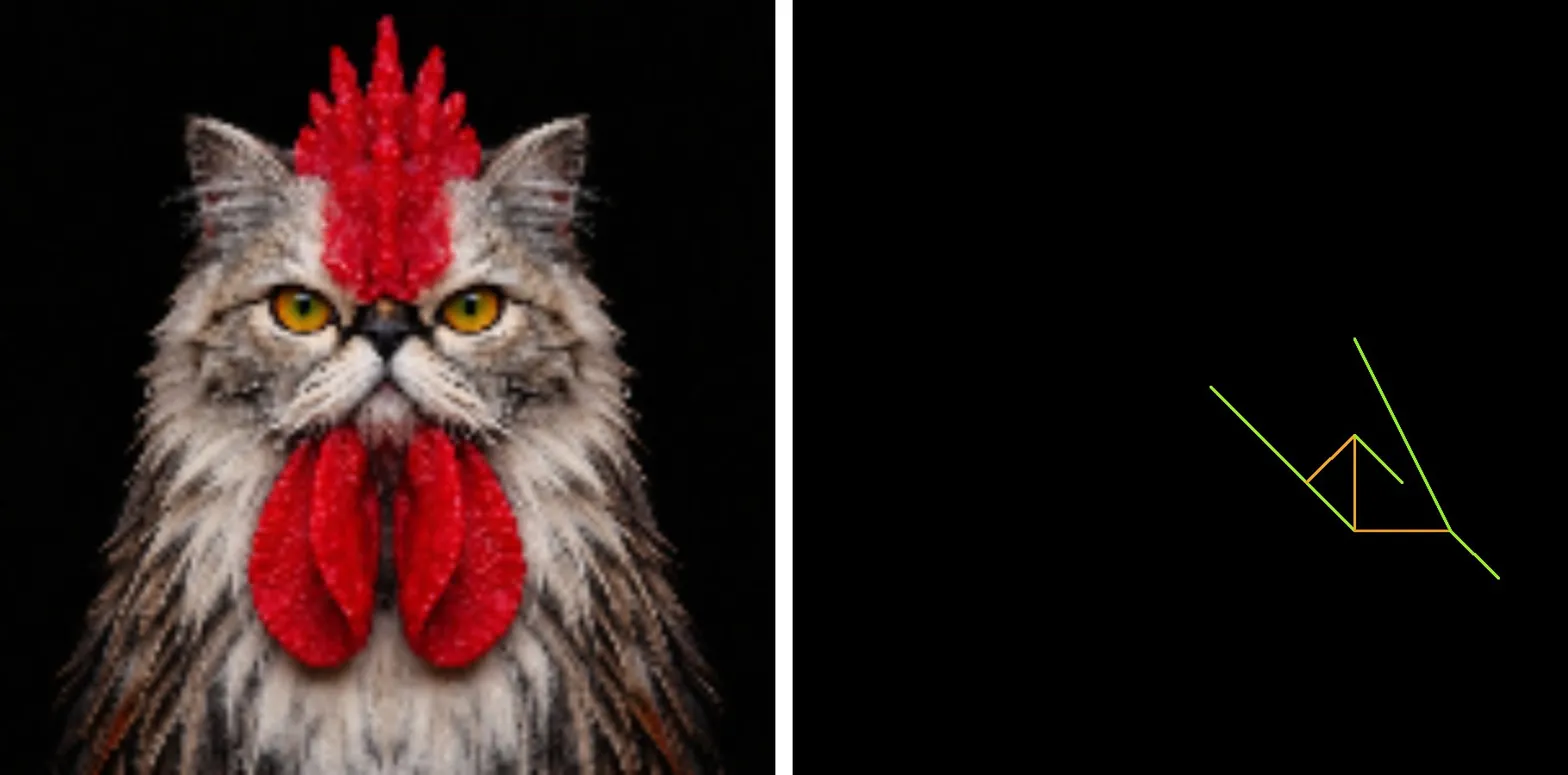
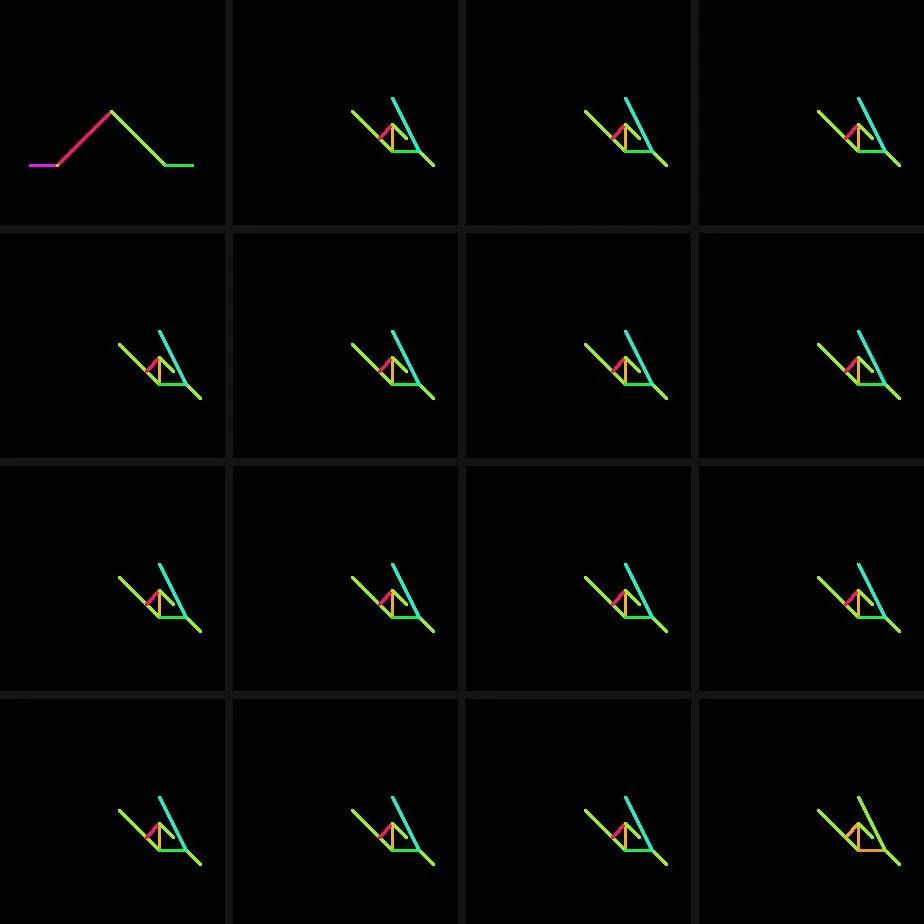